In [7]:
import numpy as np
import skimage.io as skio
import glob, os

In [10]:
parent_dir = '../../Multi-view_infrared_dataset'

In [11]:
os.listdir(parent_dir)

['view_00',
 'view_01',
 'view_02',
 'view_03',
 'view_04',
 'view_05',
 'view_06',
 'view_07',
 'view_08',
 'view_09',
 'view_10',
 'view_11',
 'view_12',
 'view_13',
 'view_14',
 'view_15']

In [14]:
files_per_view = sorted(glob.glob(f'{parent_dir}/view_00/*.tiff'))

In [15]:
len(files_per_view)

150

In [16]:
files = files_per_view[:16]
stack = np.array([skio.imread(f).astype(np.float64) for f in files])

In [17]:
mean_img = stack.mean(axis=0)

In [18]:
residual = stack - mean_img

In [19]:
temporal_std = stack.std(axis=0)

In [20]:
print("전체 밝기 범위:", stack.min(), "~", stack.max())
print("픽셀별 시간 변동 평균:", temporal_std.mean())
print("변동이 큰 픽셀 vs 작은 픽셀:", temporal_std.max(), temporal_std.min())

전체 밝기 범위: 2365.0 ~ 2597.0
픽셀별 시간 변동 평균: 4.265314405795892
변동이 큰 픽셀 vs 작은 픽셀: 11.627015954233485 1.1162856937182344


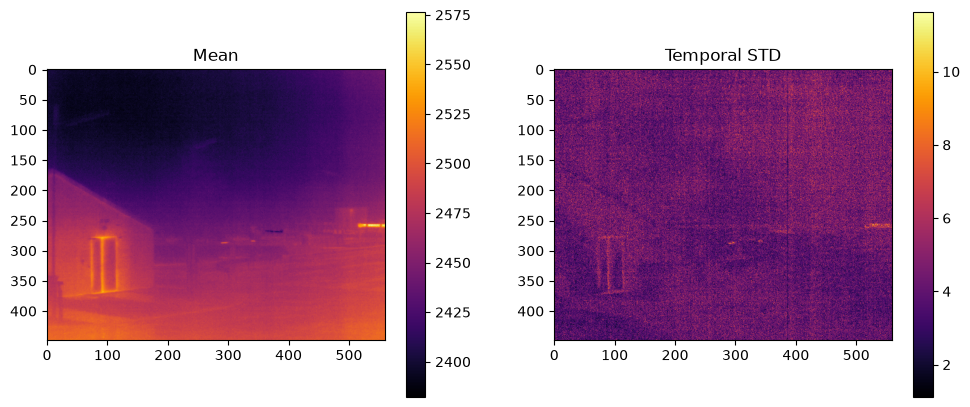

In [23]:
import matplotlib.pyplot as plt

# (1) 평균 영상 - 고정 FPN이 보이는지
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(mean_img, cmap='inferno')
plt.title('Mean')
plt.colorbar()

# (2) 시간 변동 맵 - 어디가 움직이는지
plt.subplot(1,2,2)
plt.imshow(temporal_std, cmap='inferno')
plt.title('Temporal STD')
plt.colorbar()
plt.show()